### Transfer learning in image classification

**In this notebook we will use transfer learning and take pre-trained model from google's Tensorflow Hub and re-train that on flowers dataset. Using pre-trained model saves lot of time and computational budget for new classification problem at hand**

In [ ]:
# Install tensorflow_hub using pip install tensorflow_hub first

In [3]:
# hide warnings
import warnings
warnings.filterwarnings("ignore")

In [1]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

c:\Workspace\MyProjects\DeepLearning\venv\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


**Make predictions using ready made model (without any training)**

**Below code works with TensorFlow 2.15 or below versions so commented it**

In [9]:
#IMAGE_SHAPE = (224, 224)

### Below code works with TensorFlow 2.15 or below versions so commented it
# classifier = tf.keras.Sequential([
#     hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
# ])

In [ ]:
IMAGE_SHAPE = (224, 224)
# Wrap hub.KerasLayer in Lambda layer
classifier = tf.keras.Sequential([
    tf.keras.layers.Lambda(lambda x: hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4")(x), 
                          input_shape=IMAGE_SHAPE+(3,))
])

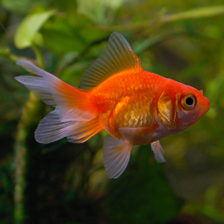

In [10]:
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [11]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [ ]:
gold_fish[np.newaxis, ...]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [13]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(1, 1001)

In [14]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(2)

In [15]:
# tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [16]:
image_labels[predicted_label_index]

'goldfish'

### Load flowers dataset

In [17]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [18]:
data_dir

'.\\datasets\\flower_photos'

In [19]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [20]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [21]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [24]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

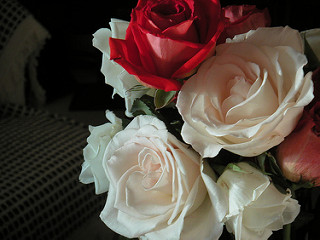

In [25]:
# import PIL library
import PIL
PIL.Image.open(str(roses[1]))

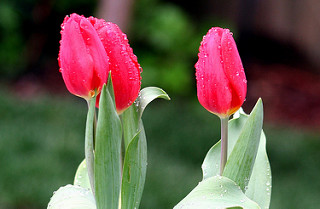

In [26]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

***Read flowers images from disk into numpy array using opencv***

In [27]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [28]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [29]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [30]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [31]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [32]:
img.shape

(240, 179, 3)

In [33]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [34]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [35]:
X = np.array(X)
y = np.array(y)

***Train test split***

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

***Preprocessing: scale images***

In [37]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

**Make prediction using pre-trained model on new flowers dataset**

In [38]:
X[0].shape

(224, 224, 3)

In [39]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [40]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

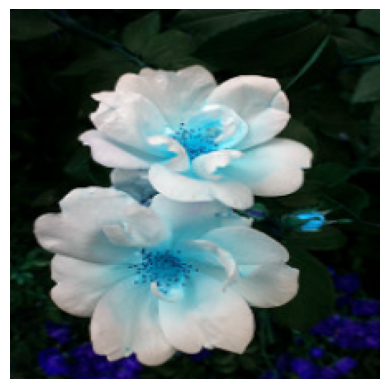

In [45]:
plt.axis('off')
plt.imshow(X[0])

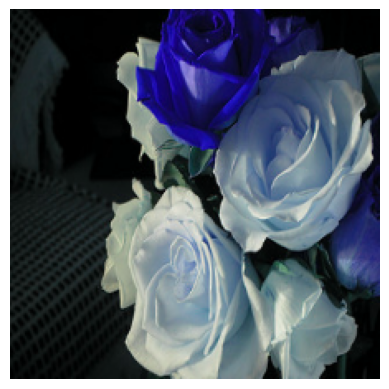

In [46]:
plt.axis('off')
plt.imshow(X[1])

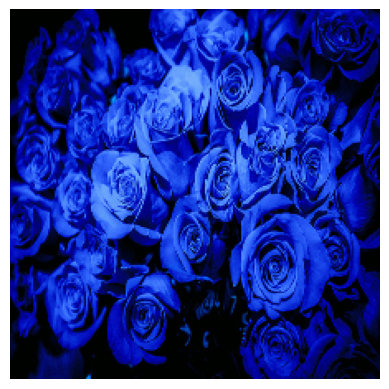

In [47]:
plt.axis('off')
plt.imshow(X[2])

In [48]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([795, 880, 795])

In [50]:
image_labels[800]

'sliding door'

### Now take pre-trained model and retrain it using flowers images

In [51]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [ ]:
num_of_flowers = 5

# Create a Sequential model with the feature extractor and a Dense layer for classification
model = tf.keras.Sequential([
  tf.keras.layers.Lambda(lambda x: hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)(x)),
  tf.keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 459ms/step - acc: 0.5682 - loss: 1.0864
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 37s 430ms/step - acc: 0.8663 - loss: 0.4077
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 36s 420ms/step - acc: 0.8923 - loss: 0.3165
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 362ms/step - acc: 0.9239 - loss: 0.2543
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 345ms/step - acc: 0.9284 - loss: 0.2403


In [ ]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 1s 23ms/step - loss: 0.3703 - acc: 0.8682


[0.37029528617858887, 0.8681917190551758]

In [56]:
# model evaluation
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=2) #verbose=2 means it will print the progress bar
print(f'\nTest accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

29/29 - 16s - 541ms/step - acc: 0.8704 - loss: 0.3794

Test accuracy: 0.8704
Test loss: 0.3794


In [57]:
def check_actual_predicted_class(test_index):
    # model predictions
    predictions = model.predict(X_test_scaled)
    score = tf.nn.softmax(predictions[test_index])

    # Display the image and prediction
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(X_test[test_index].astype("uint8"))
    plt.title(f'Predicted: {list(flowers_images_dict.keys())[np.argmax(score)]} ({100 * np.max(score):.2f}%)')
    plt.show()

    # print actual class and actual class name
    actual_class = y_test[test_index]
    actual_class_name = list(flowers_images_dict.keys())[actual_class]
    print(f'Actual class: {actual_class}')
    print(f'Actual class name: {actual_class_name}')
    print(f'Actual path: {str(flowers_images_dict[actual_class_name][test_index])}')
    
    print('=================================')
    pred_class = np.argmax(score)
    pred_class_name = list(flowers_images_dict.keys())[pred_class]
    print(f'Predicted class: {pred_class}')
    print(f'Predicted class name: {pred_class_name}')
    print(f'Predicted path: {str(flowers_images_dict[pred_class_name][test_index])}')
    print(f'Predicted class score: {100 * np.max(score):.2f}%')


29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 450ms/step


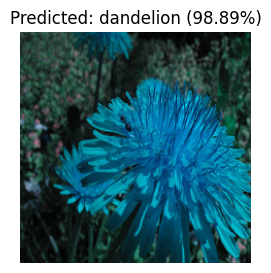

Actual class: 2
Actual class name: dandelion
Actual path: datasets\flower_photos\dandelion\10443973_aeb97513fc_m.jpg
Predicted class: 2
Predicted class name: dandelion
Predicted path: datasets\flower_photos\dandelion\10443973_aeb97513fc_m.jpg
Predicted class score: 98.89%


In [58]:
check_actual_predicted_class(4)

In [65]:
def check_actual_predicted_class_by_path(image_path):
    #image_path = str(flowers_images_dict['tulips'][90])
    # Load the image
    img = cv2.imread(image_path)
    resized_img = cv2.resize(img, (224, 224))
    img_scaled = resized_img / 255.0
    img_scaled = np.expand_dims(img_scaled, axis=0)  # Add batch dimension

    # model predictions
    predictions = model.predict(img_scaled)
    score = tf.nn.softmax(predictions[0])

    pred_class = np.argmax(score)
    pred_class_name = list(flowers_images_dict.keys())[pred_class] 

    # Print actual class and actual class name
    print(f'Image Path: {image_path}')
    actual_class_name = image_path.split("\\")[-2]
    print(f'Actual class name: {actual_class_name}\n') 
        
    print(f'Predicted class: {pred_class}')
    print(f'Predicted class name: {pred_class_name}')
    print(f'Predicted class score: {100 * np.max(score):.2f}%')

    # Display the image and prediction
    plt.figure(figsize=(3, 3))
    plt.axis('off')
    plt.imshow(resized_img.astype("uint8"))
    plt.title(f'Predicted: {list(flowers_images_dict.keys())[np.argmax(score)]} ({100 * np.max(score):.2f}%)')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Image Path: datasets\flower_photos\roses\12045735155_42547ce4e9_n.jpg
Actual class name: roses

Predicted class: 0
Predicted class name: roses
Predicted class score: 69.52%


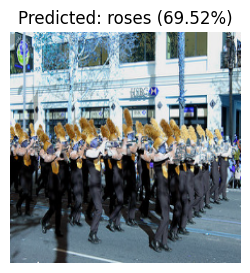

In [68]:
path = str(flowers_images_dict['roses'][10])
check_actual_predicted_class_by_path(path)